In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from utils import parse_latencies_trt, parse_power_log, get_power_index, compute_layer_metrics_by_cycle

In [2]:
DATA_PATH = Path('../raw_data/single_conv_layer_trt')

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 3576245.017657479


## Single Convolution Layers


### Kernel 1 Stride 1 Output 3

In [4]:
model_name = 'conv_k1_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 66.28it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o3: 17278
Number of TensorRT layers in conv_k1_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.771303 seconds


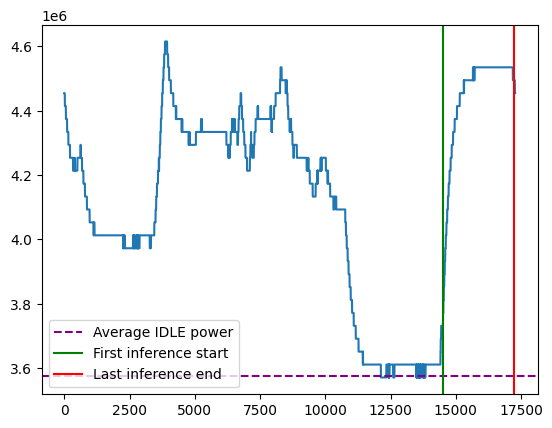

In [6]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [7]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k1 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1594994.55it/s]


In [8]:
metrics_df_k1.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,5.880000e+02,588.000000,3000.000000
mean,1500.500000,4.461032e+06,884787.472138,0.273359
std,866.169729,1.485564e+05,148556.378890,0.053302
min,1.000000,3.731904e+06,155658.982343,0.251808
25%,750.750000,4.494336e+06,918090.982343,0.274720
50%,1500.500000,4.534464e+06,958218.982343,0.275648
75%,2250.250000,4.534464e+06,958218.982343,0.276352
max,3000.000000,4.534464e+06,958218.982343,2.946720


In [9]:
metrics_df_k1.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     588
layer_power_excluding_idle_power_micro_watt     588
layer_run_time                                 3000
dtype: int64

<Axes: >

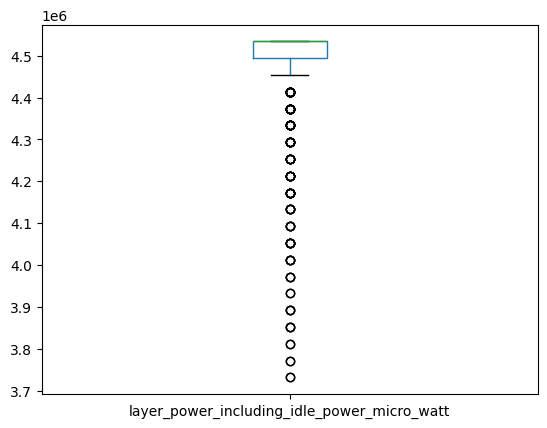

In [10]:
metrics_df_k1.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 1 Output 6

In [11]:
model_name = 'conv_k1_s1_o6'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 70.41it/s]


In [12]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o6: 17007
Number of TensorRT layers in conv_k1_s1_o6: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.679834 seconds


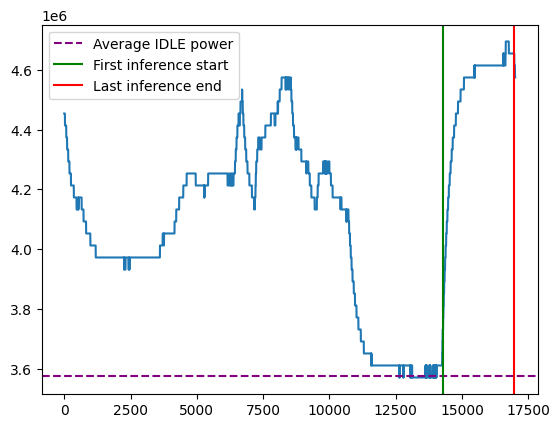

In [13]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [14]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k2 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1937621.19it/s]


In [15]:
metrics_df_k2.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,5.860000e+02,5.860000e+02,3000.000000
mean,1500.500000,4.542134e+06,9.658885e+05,0.275116
std,866.169729,1.682858e+05,1.682858e+05,0.007800
min,1.000000,3.731904e+06,1.556590e+05,0.253248
25%,750.750000,4.534464e+06,9.582190e+05,0.276448
50%,1500.500000,4.614720e+06,1.038475e+06,0.277184
75%,2250.250000,4.614720e+06,1.038475e+06,0.277856
max,3000.000000,4.694976e+06,1.118731e+06,0.323584


In [16]:
metrics_df_k2.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     586
layer_power_excluding_idle_power_micro_watt     586
layer_run_time                                 3000
dtype: int64

<Axes: >

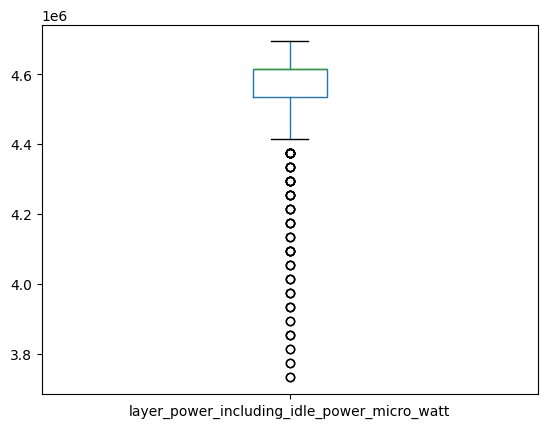

In [17]:
metrics_df_k2.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 1 Output 12

In [18]:
model_name = 'conv_k1_s1_o12'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 42.55it/s]


In [19]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o12: 17255
Number of TensorRT layers in conv_k1_s1_o12: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.8441 seconds


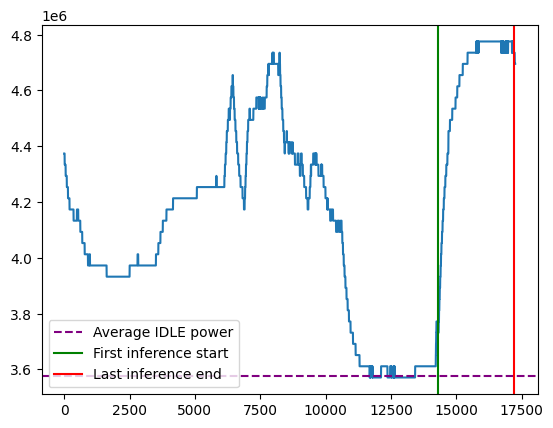

In [20]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [21]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k3 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 60783.49it/s]


In [22]:
metrics_df_k3.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,6.520000e+02,6.520000e+02,3000.000000
mean,1500.500000,4.660695e+06,1.084450e+06,0.280937
std,866.169729,2.047775e+05,2.047775e+05,0.022526
min,1.000000,3.731904e+06,1.556590e+05,0.258080
25%,750.750000,4.654848e+06,1.078603e+06,0.281248
50%,1500.500000,4.735104e+06,1.158859e+06,0.282112
75%,2250.250000,4.775232e+06,1.198987e+06,0.283040
max,3000.000000,4.775232e+06,1.198987e+06,0.755488


In [23]:
metrics_df_k3.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     652
layer_power_excluding_idle_power_micro_watt     652
layer_run_time                                 3000
dtype: int64

<Axes: >

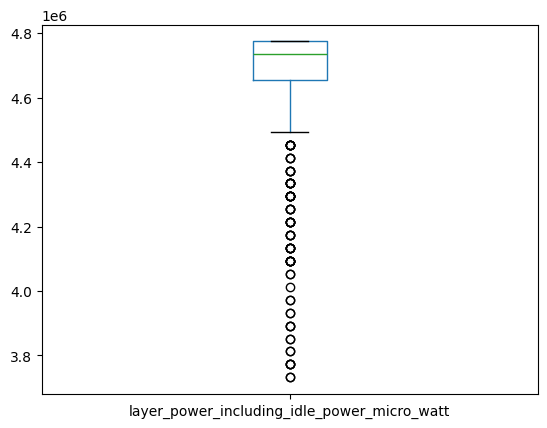

In [24]:
metrics_df_k3.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 1 Output 24

In [25]:
model_name = 'conv_k1_s1_o24'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 72.01it/s]


In [26]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o24: 17524
Number of TensorRT layers in conv_k1_s1_o24: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.936046 seconds


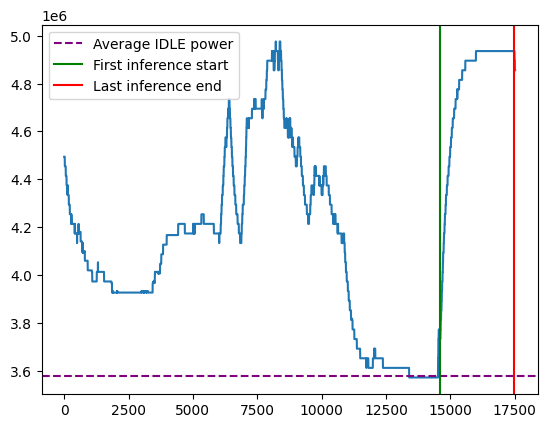

In [27]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [28]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k4 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1132881.25it/s]


In [29]:
metrics_df_k4.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,8.250000e+02,8.250000e+02,3000.000000
mean,1500.500000,4.814339e+06,1.238094e+06,0.379417
std,866.169729,2.282365e+05,2.282365e+05,0.009036
min,1.000000,3.731904e+06,1.556590e+05,0.341248
25%,750.750000,4.815360e+06,1.239115e+06,0.379200
50%,1500.500000,4.935744e+06,1.359499e+06,0.381072
75%,2250.250000,4.935744e+06,1.359499e+06,0.383200
max,3000.000000,4.935744e+06,1.359499e+06,0.421856


In [30]:
metrics_df_k4.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     825
layer_power_excluding_idle_power_micro_watt     825
layer_run_time                                 3000
dtype: int64

<Axes: >

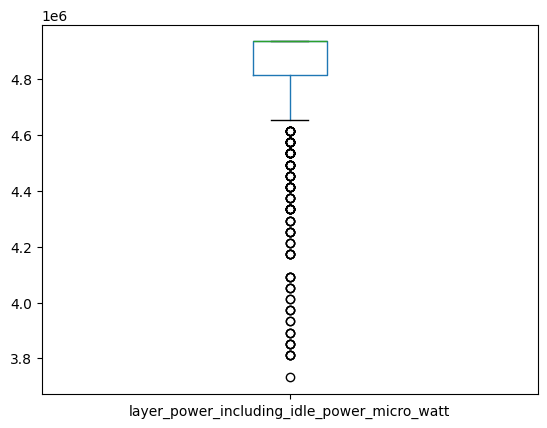

In [31]:
metrics_df_k4.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 1 Output 48

In [32]:
model_name = 'conv_k1_s1_o48'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 51.22it/s]


In [33]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o48: 18563
Number of TensorRT layers in conv_k1_s1_o48: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.443237 seconds


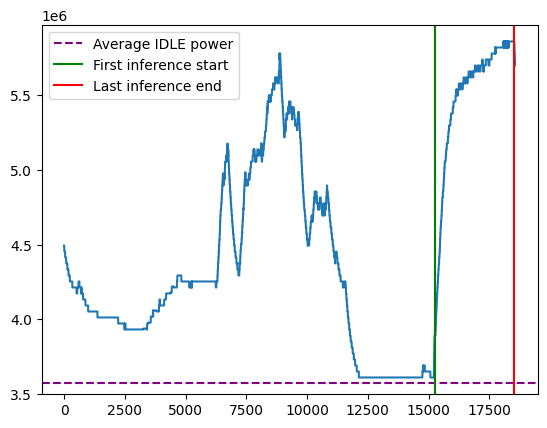

In [34]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [35]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k5 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1175204.26it/s]


In [36]:
metrics_df_k5.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.274000e+03,1.274000e+03,3000.000000
mean,1500.500000,5.526986e+06,1.950741e+06,0.590957
std,866.169729,4.040801e+05,4.040801e+05,0.075636
min,1.000000,3.892416e+06,3.161710e+05,0.526400
25%,750.750000,5.497536e+06,1.921291e+06,0.550752
50%,1500.500000,5.658048e+06,2.081803e+06,0.552224
75%,2250.250000,5.778432e+06,2.202187e+06,0.659040
max,3000.000000,5.858688e+06,2.282443e+06,1.798816


In [37]:
metrics_df_k5.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    1274
layer_power_excluding_idle_power_micro_watt    1274
layer_run_time                                 3000
dtype: int64

<Axes: >

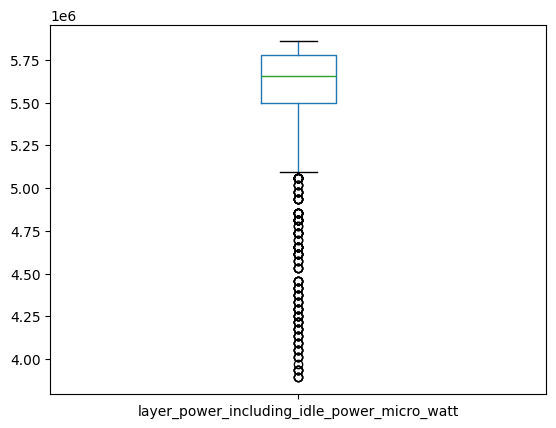

In [38]:
metrics_df_k5.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

## Output shape Plot

Text(0.5, 0, 'Output shape')

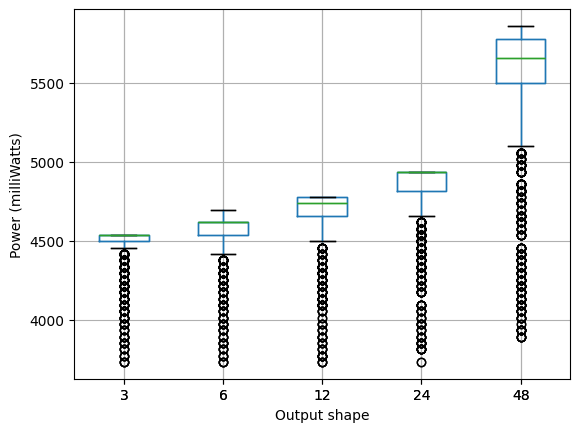

In [39]:
df = pd.concat(
    [
        metrics_df_k1["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k2["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k3["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k4["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k5["layer_power_including_idle_power_micro_watt"] * 1e-3,
    ],
    axis=1,
)

# set column names (will be displayed as plot labels)
df.columns = ['3', '6', '12', '24', '48']  

# use pandas' boxplot method
df.boxplot().set_ylabel('Power (milliWatts)')
df.boxplot().set_xlabel('Output shape')